In [1]:
import sys
import os

# Adjust the path so Python can find 'modules' from the root folder
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

In [2]:
import cv2
from modules import full_preprocessing_pipeline,preprocess_invoice

def read_image(path):
    image = cv2.imread(path)
    if image is None:
        raise ValueError(f"Could not load image from path: {path}")
    return image


In [3]:
import pytesseract
from pytesseract import Output
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

custom_config = r'--oem 3 --psm 6'  # 6 = Assume a uniform block of text
def extract_ocr_data(image, lang="ara+eng"):
    # Use PSM 6: Assume a single uniform block of text (good for invoices)
    config = "--psm 6"
    data = pytesseract.image_to_data(image, lang=lang, config=custom_config, output_type=Output.DICT)
    return data


In [16]:
import matplotlib.pyplot as plt

def draw_boxes(image, ocr_data, min_conf=50):
    image_copy = image.copy()
    n_boxes = len(ocr_data['level'])
    for i in range(n_boxes):
        if int(ocr_data['conf'][i]) > min_conf:
            (x, y, w, h) = (ocr_data['left'][i], ocr_data['top'][i],
                            ocr_data['width'][i], ocr_data['height'][i])
            text = ocr_data['text'][i]
            cv2.rectangle(image_copy, (x, y), (x + w, y + h), (0, 0, 255), 1)
            cv2.putText(image_copy, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 
                        0.5, (255, 0, 0), 1, cv2.LINE_AA)

    # Convert BGR to RGB for display
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
    plt.title("OCR Bounding Boxes")
    plt.axis("off")
    plt.show()


In [5]:
import pandas as pd

def ocr_data_to_dataframe(ocr_data):
    df = pd.DataFrame(ocr_data)
    df = df[df['conf'].astype(int) > 50]  # Filter low-confidence words
    df = df[df['text'].str.strip() != ''] # Remove empty text
    return df.reset_index(drop=True)


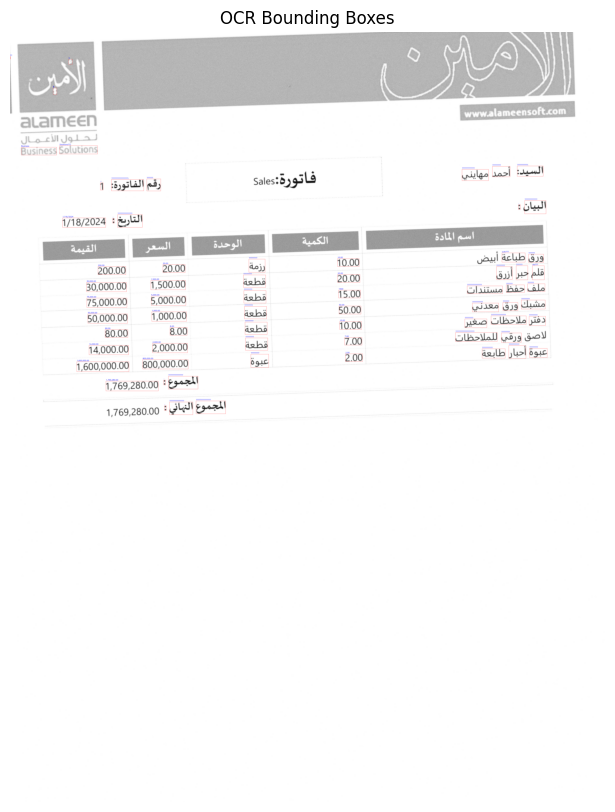

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
0,5,1,1,1,1,1,502,233,32,44,52,0
1,5,1,1,1,1,2,0,210,2,22,72,ظ
2,5,1,1,1,3,1,369,479,32,58,71,$
3,5,1,1,1,6,1,96,987,303,67,95,Business
4,5,1,1,1,6,2,424,974,326,71,95,Solutions‏


In [19]:
image = cv2.imread("D:\\desktop\\Graduation Project\\GRAD_PROJECT\\convert2Scanned_Image\\scanned_output\\invoice_1_t2_page_1.png")
resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
ocr_data = extract_ocr_data(gray)
draw_boxes(gray_bgr, ocr_data)
df = ocr_data_to_dataframe(ocr_data)
df.head()

In [18]:
df

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
0,5,1,1,1,1,1,502,233,32,44,52,0
1,5,1,1,1,1,2,0,210,2,22,72,ظ
2,5,1,1,1,3,1,369,479,32,58,71,$
3,5,1,1,1,6,1,96,987,303,67,95,Business
4,5,1,1,1,6,2,424,974,326,71,95,Solutions‏
...,...,...,...,...,...,...,...,...,...,...,...,...
64,5,1,1,1,17,2,1317,2983,16,42,92,:
65,5,1,1,1,17,3,822,2992,449,84,75,"1,769,280.00"
66,5,1,1,1,18,1,1594,3162,254,110,92,المجموع
67,5,1,1,1,18,2,1366,3171,201,109,72,النهائي


In [8]:
import easyocr
reader = easyocr.Reader(['ar'])
image = cv2.imread("D:\\desktop\\Graduation Project\\GRAD_PROJECT\\convert2Scanned_Image\\scanned_output\\invoice_1_t2_page_1.png")
resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
result = reader.readtext(gray)
print(result)
import matplotlib.pyplot as plt
import cv2



Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
d:\desktop\Graduation Project\GRAD_PROJECT\invoice-ai-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[[[[np.int32(91), np.int32(209)], [np.int32(727), np.int32(209)], [np.int32(727), np.int32(598)], [np.int32(91), np.int32(598)]], 'الأمإن', np.float64(0.3671534043562986)], [[[np.int32(3879), np.int32(619)], [np.int32(4782), np.int32(619)], [np.int32(4782), np.int32(759)], [np.int32(3879), np.int32(759)]], 'هف:شداد ٣', np.float64(0.015202002645823495)], [[[np.int32(65), np.int32(684)], [np.int32(769), np.int32(684)], [np.int32(769), np.int32(856)], [np.int32(65), np.int32(856)]], '٥٧٥٨٤٤٥', np.float64(0.3156402430011272)], [[[np.int32(78), np.int32(848)], [np.int32(768), np.int32(848)], [np.int32(768), np.int32(984)], [np.int32(78), np.int32(984)]], 'لحلول الأعسمال', np.float64(0.2981451183859518)], [[[np.int32(83), np.int32(960)], [np.int32(772), np.int32(960)], [np.int32(772), np.int32(1071)], [np.int32(83), np.int32(1071)]], '٥٨5ز٥٧؟ 55زء ', np.float64(0.0038682904510806398)], [[[np.int32(3855), np.int32(1140)], [np.int32(4313), np.int32(1140)], [np.int32(4313), np.int32(1285)], [np

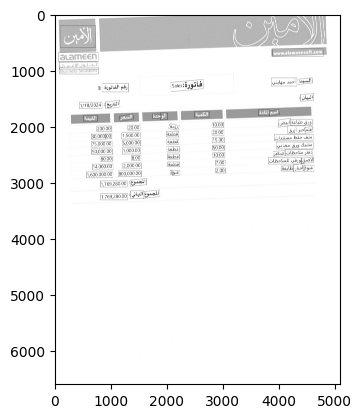

In [10]:
import numpy as np
for detection in result:
    box = detection[0]
    pts = [tuple(map(int, pt)) for pt in box]
    cv2.polylines(gray, [np.array(pts)], isClosed=True, color=(0, 255, 0), thickness=2)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.show()


In [11]:
for detection in result:
    text = detection[1]
    confidence = detection[2]
    print(f'Text: {text} | Confidence: {confidence:.2f}')

Text: الأمإن | Confidence: 0.37
Text: هف:شداد ٣ | Confidence: 0.02
Text: ٥٧٥٨٤٤٥ | Confidence: 0.32
Text: لحلول الأعسمال | Confidence: 0.30
Text: ٥٨5ز٥٧؟ 55زء  | Confidence: 0.00
Text: أحمد مهايني | Confidence: 0.68
Text: 1 | Confidence: 0.99
Text: رقم الفاتورة : | Confidence: 0.92
Text: 1/18/2024 | Confidence: 1.00
Text: حدة | Confidence: 0.99
Text: الو | Confidence: 1.00
Text: الكمية | Confidence: 0.90
Text: المادة | Confidence: 0.68
Text: القيمة | Confidence: 0.89
Text: ورق طباعة | Confidence: 0.69
Text: 10.00 | Confidence: 0.92
Text: 200.00 | Confidence: 0.51
Text: 20.00 | Confidence: 0.87
Text: حبر أزرق | Confidence: 0.67
Text: .00 | Confidence: 0.69
Text: 1,500.00 | Confidence: 0.99
Text: قطعة | Confidence: 1.00
Text: 20.00 | Confidence: 1.00
Text: 30,000. | Confidence: 0.63
Text: ملف حفظ مستندات | Confidence: 0.69
Text: قطعة | Confidence: 1.00
Text: 15.00 | Confidence: 0.91
Text: 75,000.00 | Confidence: 0.92
Text: 5,000.00 | Confidence: 1.00
Text: مشبك ورق معدني | Confidence: 0.